In [2]:
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_groq import ChatGroq
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun #requires this for arxiv query run tool
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
from typing_extensions import TypedDict
#REDUCERS
from typing import Annotated
from langgraph.graph.message import add_messages

C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
wiki_api_wrapper = WikipediaAPIWrapper(top_k_results=10, doc_content_chars_max=500)
arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=10, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=wiki_api_wrapper)
arxiv = ArxivQueryRun(api_wrapper=arxiv_api_wrapper)
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")
llm = ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b"
)

In [4]:
# arxiv.invoke("is there any research papers published by openText?") #testing Arxiv tool
# wiki.invoke("who is bramhanandham") #testing wikipedia tool -> this is giving irrelevant results

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()
# tavily.invoke("provide me the latest news about openText business networks") #testing Tavily Search tool

C:\Users\ybalasaraswa\AppData\Local\Temp\ipykernel_42032\2659482886.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'OpenText in the News | Recent Articles and Media Coverage',
  'url': 'https://www.opentext.com/about/in-the-news',
  'content': '##### OpenText™ Business Network Aviator™\n\nGain better insights with generative AI for supply chains\n\n##### OpenText™ Content Aviator™\n\nPower work with AI content management and an intelligent AI content assistant\n\n##### OpenText™ Cybersecurity Aviator™\n\nImprove your security posture with AI cybersecurity and agile threat detection\n\n##### OpenText™ DevOps Aviator™\n\nEnable faster app delivery, development, and automated software testing\n\n##### OpenText™ Experience Aviator™\n\nElevate customer communications and experiences for customer success\n\n##### OpenText™ Fax Aviator™\n\nTurn every fax into instant action with AI\n\n##### OpenText™ Service Management Aviator™\n\nEmpower users, service agents, and IT staff to find the answers they need\n\n⟵Back to Solutions menu\n\n### Industry [...] ##### BI, Visualization and Reporting\n\n O

In [6]:
tools = [arxiv, wiki, tavily]

In [7]:
#binding out tools with the LLM
llm_with_tools = llm.bind_tools(tools=tools)

In [9]:

llm_with_tools.invoke([
    HumanMessage(content="provide me the latest news about openText business networks")
])


AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants latest news about OpenText Business Networks. Need to retrieve current news. Use search tool. Use tavily_search_results_json likely.', 'tool_calls': [{'id': 'fc_facf44e0-e06f-4553-a6bf-6a15a3bff08b', 'function': {'arguments': '{"query":"latest news OpenText Business Networks"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 295, 'total_tokens': 361, 'completion_time': 0.141342806, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.06866643, 'prompt_tokens_details': None, 'queue_time': 2.035662921, 'total_time': 0.210009236}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46d8af1c62', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cf716-df23-7e41-8cde-66c078fff100-0', tool_calls=[{'name': 'tavily_search_results

### Building a ChatBot with multiple tools using LangGraph

In [10]:
class State(TypedDict):
    """
    Messages have the type ""List"" the add_messages function
     in the annotations defines how the state key should be updated
     in this case it updates messages to the list rather than overriding them
    """
    messages: Annotated[list[MessagesState], add_messages]

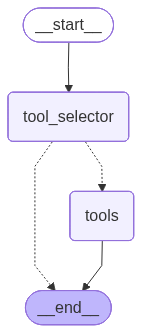

In [11]:
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition

#Node definition
def tool_selector(state: State):
    return {
        "messages": llm_with_tools.invoke(state['messages'])
    }

# Builder graph
builder = StateGraph(MessagesState)
builder.add_node("tool_selector", tool_selector)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_selector")
builder.add_conditional_edges("tool_selector", tools_condition)
builder.add_edge("tools",END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
messages = graph.invoke({"messages": HumanMessage("what is the latest research on openText business network?")}) #tavily Tool call
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is the latest research on openText business network?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_7ae7d883-cd38-40e9-b962-a4634f58a199)
 Call ID: fc_7ae7d883-cd38-40e9-b962-a4634f58a199
  Args:
    query: OpenText Business Network latest research
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "What's New in OpenText Business Network Cloud", "url": "https://blogs.opentext.com/whats-new-opentext-business-network-cloud/", "content": "AI continues to take center stage in Business Network, making it easier for users to analyze integration health and act faster:\n\nA screenshot of a computer\n\nAI-generated content may be incorrect., Picture\n\nA screenshot of a computer\n\nAI-generated content may be incorrect., Picture\n\nTrading Grid Insights Err

In [13]:
messages = graph.invoke({"messages": HumanMessage("what are the latest research papers about Quantum computing?")}) #Arxiv tool call
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what are the latest research papers about Quantum computing?
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_475e1152-ad6f-4ac7-a817-ccd70b4d1be8)
 Call ID: fc_475e1152-ad6f-4ac7-a817-ccd70b4d1be8
  Args:
    query: quantum computing
================================= Tool Message =================================
Name: arxiv

Published: 2022-11-04
Title: Tierkreis: A Dataflow Framework for Hybrid Quantum-Classical Computing
Authors: Seyon Sivarajah, Lukas Heidemann, Alan Lawrence, Ross Duncan
Summary: We present Tierkreis, a higher-order dataflow graph program representation and runtime designed for compositional, quantum-classical hybrid algorithms. The design of the system is motivated by the remote nature of quantum computers, the need for hybrid algorithms to involve cloud and distributed computing, and the long-


In [14]:
messages = graph.invoke({"messages": HumanMessage("what is Operation Epic Fury? ")}) #tavily Tool call
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is Operation Epic Fury? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_d00cddec-5cfd-406b-b5e9-fa992dc17176)
 Call ID: fc_d00cddec-5cfd-406b-b5e9-fa992dc17176
  Args:
    query: Operation Epic Fury
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "What is Operation Epic Fury?", "url": "https://www.jagranjosh.com/general-knowledge/what-is-operation-epic-fury-1820006691-1", "content": "### Show Key Points\n\nOperation Epic Fury: On February 28, 2026, the United States and Israel launched a massive, coordinated military campaign codenamed Operation Epic Fury against Iran. The operation involves air and naval strikes targeting Iranian military command nodes, missile infrastructure, and key government establishments. The campaign follows stalled nucle